<a href="https://colab.research.google.com/github/sushants05-ops/ECGR-4105---Intro-to-Machine-Learning/blob/main/ECGR_4105_Homework_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cancer dataset shape: (569, 33)
Housing dataset shape: (545, 13)

Problem 1
Cancer training samples: 455
Cancer evaluation samples: 114

SVM Results
Model  Kernel  Accuracy  Precision   Recall       F1
  SVM  linear  0.964912   1.000000 0.904762 0.950000
  SVM    poly  0.885965   1.000000 0.690476 0.816901
  SVM     rbf  0.973684   1.000000 0.928571 0.962963
  SVM sigmoid  0.947368   0.973684 0.880952 0.925000


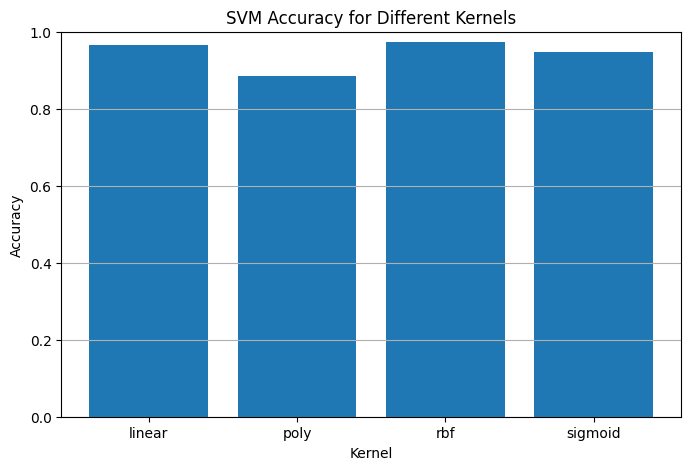

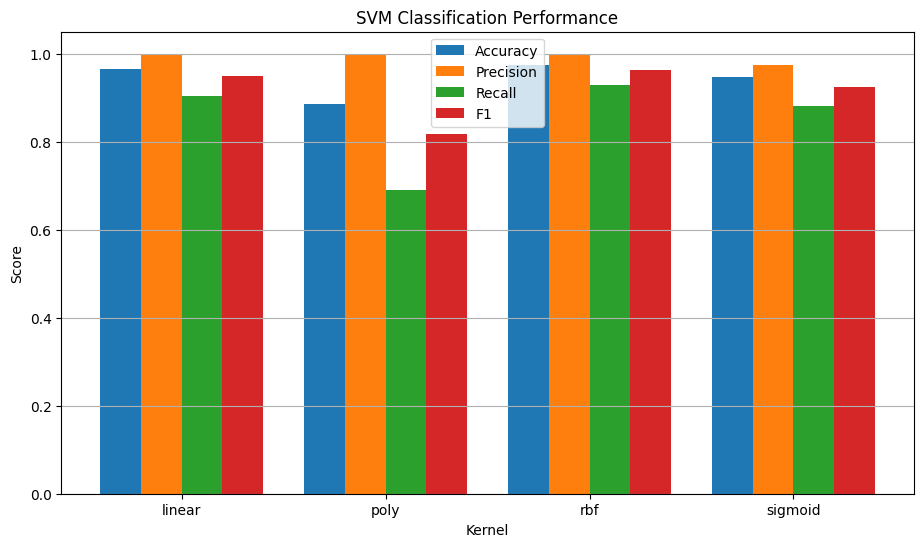


RBF SVM Confusion Matrix
[[72  0]
 [ 3 39]]


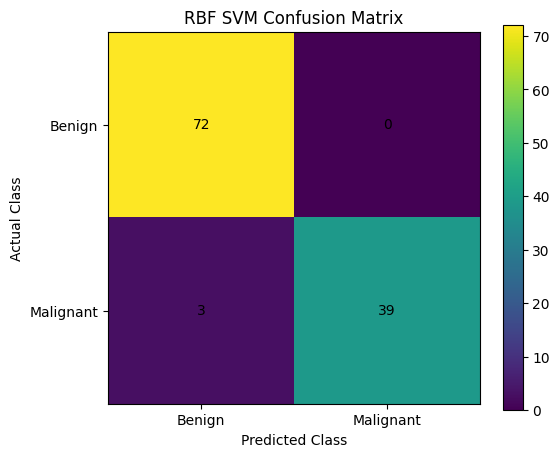


Homework 3 Logistic Regression
Accuracy: 0.9385964912280702
Precision: 0.9487179487179487
Recall: 0.8809523809523809
F1: 0.9135802469135802

Homework 3 Logistic Regression with L2 Weight Penalty
Accuracy: 0.9649122807017544
Precision: 0.975
Recall: 0.9285714285714286
F1: 0.9512195121951219

Homework 3 vs Homework 4 Classification
              Model     Kernel  Accuracy  Precision   Recall       F1
                SVM     linear  0.964912   1.000000 0.904762 0.950000
                SVM       poly  0.885965   1.000000 0.690476 0.816901
                SVM        rbf  0.973684   1.000000 0.928571 0.962963
                SVM    sigmoid  0.947368   0.973684 0.880952 0.925000
Logistic Regression       None  0.938596   0.948718 0.880952 0.913580
Logistic Regression L2 Penalty  0.964912   0.975000 0.928571 0.951220


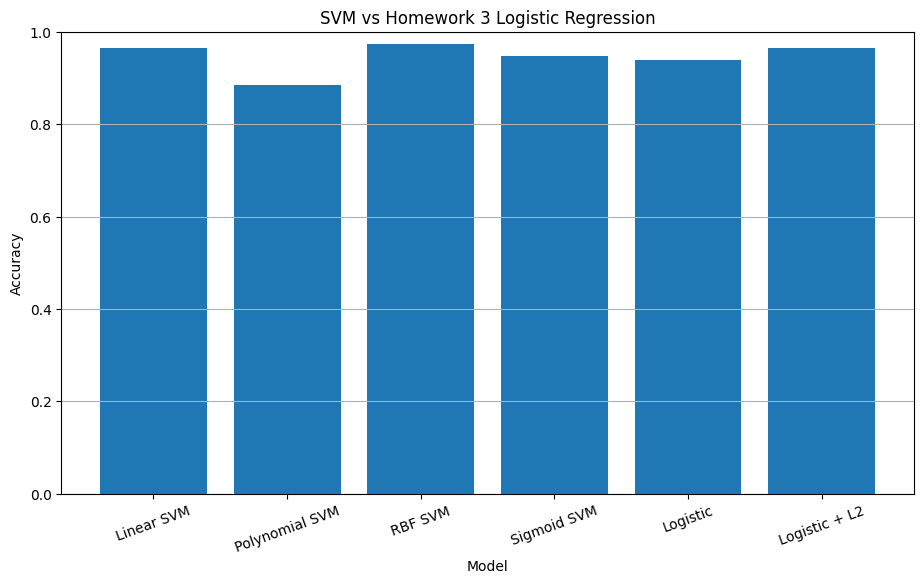


Problem 2
Housing training samples: 436
Housing evaluation samples: 109

Homework 1 Gradient Descent Results
 Learning Rate  Final Loss       R2         RMSE           MAE
          0.01    0.161328 0.643613 1.342156e+06 979146.936919
          0.03    0.161328 0.643613 1.342156e+06 979146.936935
          0.05    0.161328 0.643613 1.342156e+06 979146.936935
          0.07    0.161328 0.643613 1.342156e+06 979146.936935
          0.10    0.161328 0.643613 1.342156e+06 979146.936935


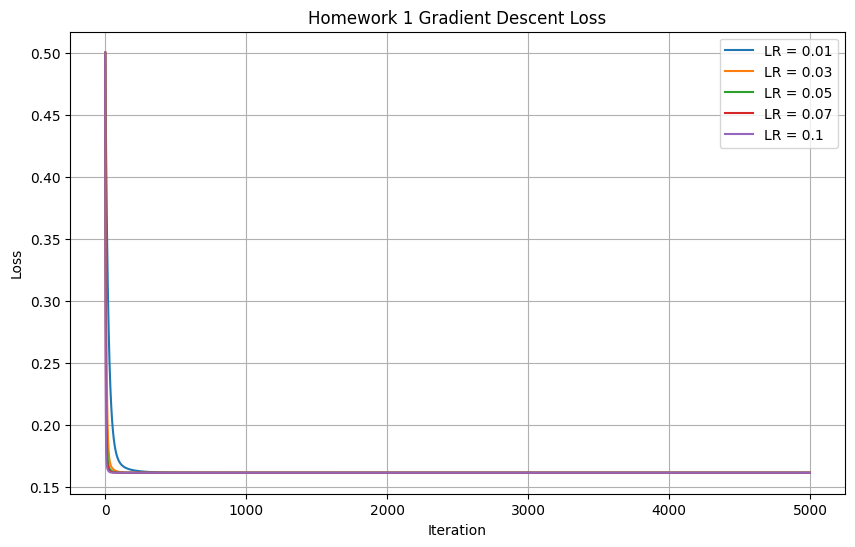


Best Gradient Descent Learning Rate: 0.01
Gradient Descent Parameters:
[-2.12098433e-16  2.97467919e-01  3.38917179e-02  3.00682273e-01
  2.07898461e-01  8.22147740e-02  5.33870012e-02  1.18395114e-01
  8.85707052e-02  2.12199470e-01  1.20385389e-01  1.53271340e-01]

SVR Results
Model  Kernel        R2         RMSE          MAE
  SVR  linear -0.096761 2.354497e+06 1.759204e+06
  SVR    poly -0.101317 2.359382e+06 1.763707e+06
  SVR     rbf -0.101451 2.359526e+06 1.763746e+06
  SVR sigmoid -0.101209 2.359267e+06 1.763527e+06

Homework 1 vs Homework 4 Regression
               Model      Kernel        R2         RMSE          MAE
HW1 Gradient Descent Linear + L2  0.643613 1.342156e+06 9.791469e+05
                 SVR      linear -0.096761 2.354497e+06 1.759204e+06
                 SVR        poly -0.101317 2.359382e+06 1.763707e+06
                 SVR         rbf -0.101451 2.359526e+06 1.763746e+06
                 SVR     sigmoid -0.101209 2.359267e+06 1.763527e+06


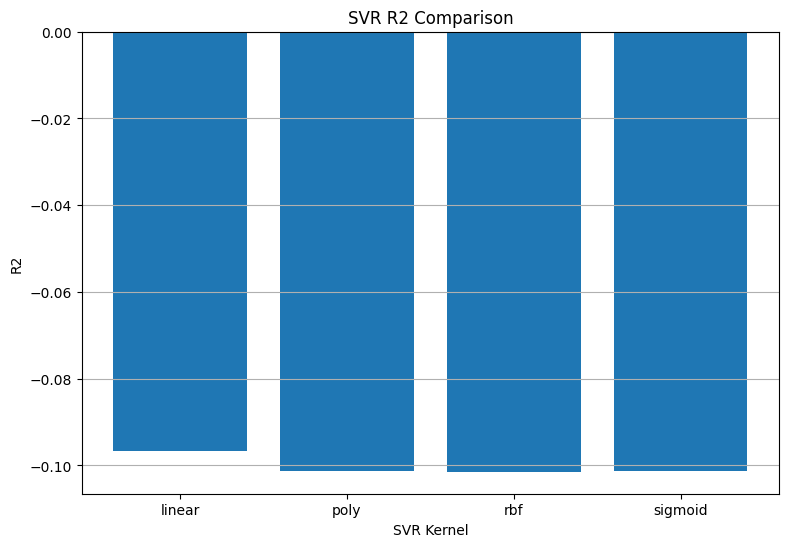

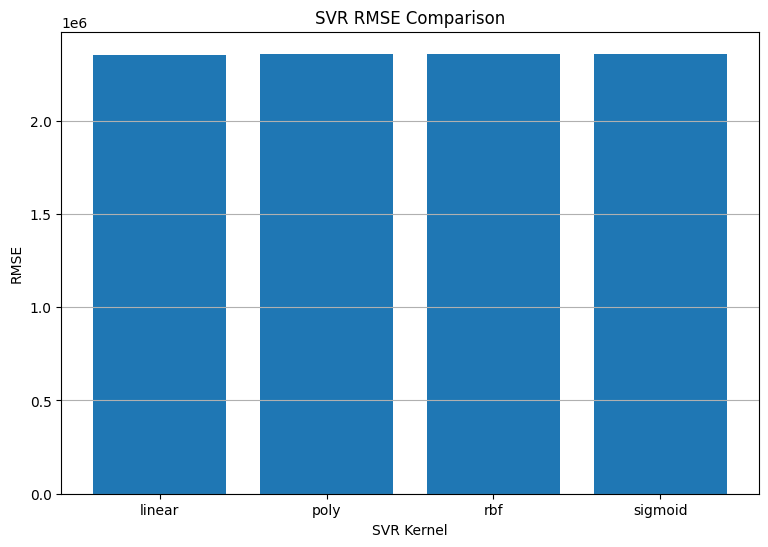

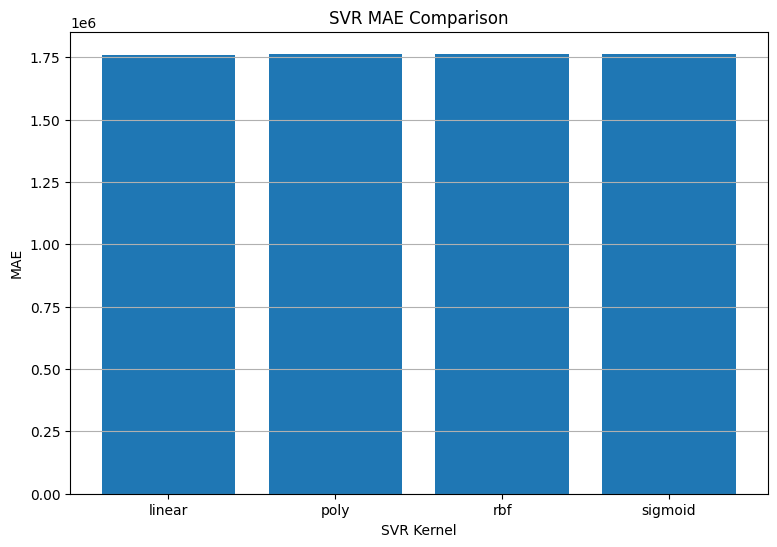

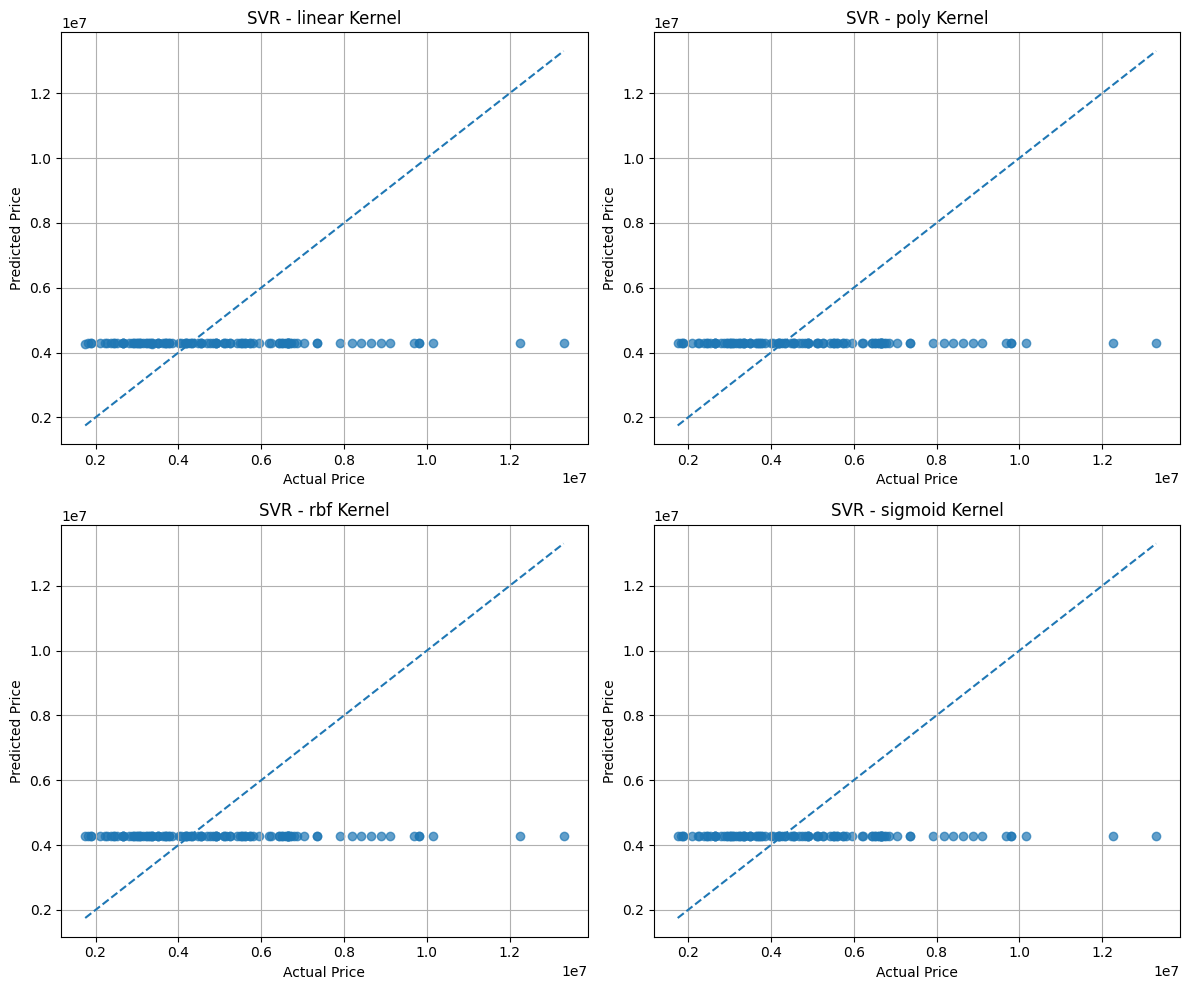


Best SVR Kernel: linear
Best SVR R2: -0.09676091777545404
Best SVR RMSE: 2354496.783254971
Best SVR MAE: 1759204.0711152502


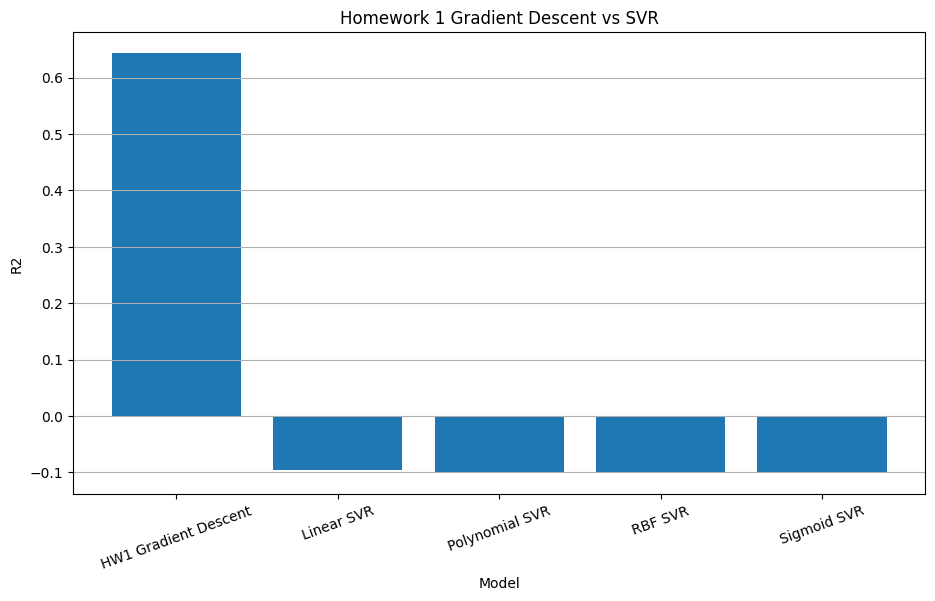

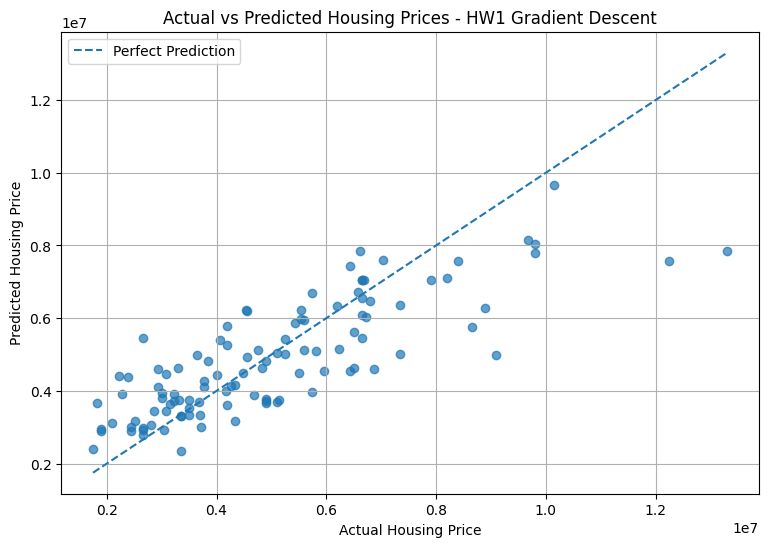



FINAL HOMEWORK 4 RESULTS


PROBLEM 1: SVM CLASSIFICATION
Model  Kernel  Accuracy  Precision   Recall       F1
  SVM  linear  0.964912   1.000000 0.904762 0.950000
  SVM    poly  0.885965   1.000000 0.690476 0.816901
  SVM     rbf  0.973684   1.000000 0.928571 0.962963
  SVM sigmoid  0.947368   0.973684 0.880952 0.925000

Homework 3 Logistic Regression
Accuracy: 0.9385964912280702
Precision: 0.9487179487179487
Recall: 0.8809523809523809
F1: 0.9135802469135802

Homework 3 Logistic Regression with L2 Penalty
Accuracy: 0.9649122807017544
Precision: 0.975
Recall: 0.9285714285714286
F1: 0.9512195121951219


PROBLEM 2: HOUSING REGRESSION
               Model      Kernel        R2         RMSE          MAE
HW1 Gradient Descent Linear + L2  0.643613 1.342156e+06 9.791469e+05
                 SVR      linear -0.096761 2.354497e+06 1.759204e+06
                 SVR        poly -0.101317 2.359382e+06 1.763707e+06
                 SVR         rbf -0.101451 2.359526e+06 1.763746e+06
              

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    r2_score,
    mean_squared_error,
    mean_absolute_error
)


# Load datasets
cancer = pd.read_csv("Cancer.csv")
housing = pd.read_csv("Housing.csv")

print("Cancer dataset shape:", cancer.shape)
print("Housing dataset shape:", housing.shape)

# Problem 1: Cancer SVM Classification
# Remove ID and empty column
X_cancer = cancer.drop(
    columns=["diagnosis", "id", "Unnamed: 32"]
)

# Convert diagnosis to binary values
y_cancer = cancer["diagnosis"].map({
    "B": 0,
    "M": 1
})

# Create 80/20 split
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer,
    y_cancer,
    test_size=0.20,
    random_state=42,
    stratify=y_cancer
)

print("\nProblem 1")
print("Cancer training samples:", len(X_train_c))
print("Cancer evaluation samples:", len(X_test_c))

# Define SVM kernels
kernels = [
    "linear",
    "poly",
    "rbf",
    "sigmoid"
]

svm_results = []

# Train each SVM kernel
for kernel in kernels:

    svm_model = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "svm",
            SVC(
                kernel=kernel,
                C=1.0,
                gamma="scale"
            )
        )
    ])

    svm_model.fit(
        X_train_c,
        y_train_c
    )

    predictions = svm_model.predict(
        X_test_c
    )

    accuracy = accuracy_score(
        y_test_c,
        predictions
    )

    precision = precision_score(
        y_test_c,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_test_c,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_test_c,
        predictions,
        zero_division=0
    )

    svm_results.append({
        "Model": "SVM",
        "Kernel": kernel,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    })

# Convert results to DataFrame
svm_results_df = pd.DataFrame(
    svm_results
)

print("\nSVM Results")
print(
    svm_results_df.to_string(
        index=False
    )
)


# Plot SVM Accuracy

plt.figure(figsize=(8, 5))

plt.bar(
    svm_results_df["Kernel"],
    svm_results_df["Accuracy"]
)

plt.xlabel("Kernel")
plt.ylabel("Accuracy")
plt.title("SVM Accuracy for Different Kernels")
plt.ylim(0, 1)
plt.grid(axis="y")

plt.show()

# Plot SVM Accuracy, Precision, Recall, and F1

x = np.arange(
    len(svm_results_df)
)

width = 0.2

plt.figure(figsize=(11, 6))

plt.bar(
    x - 1.5 * width,
    svm_results_df["Accuracy"],
    width,
    label="Accuracy"
)

plt.bar(
    x - 0.5 * width,
    svm_results_df["Precision"],
    width,
    label="Precision"
)

plt.bar(
    x + 0.5 * width,
    svm_results_df["Recall"],
    width,
    label="Recall"
)

plt.bar(
    x + 1.5 * width,
    svm_results_df["F1"],
    width,
    label="F1"
)

plt.xticks(
    x,
    svm_results_df["Kernel"]
)

plt.xlabel("Kernel")
plt.ylabel("Score")
plt.title(
    "SVM Classification Performance"
)

plt.ylim(0, 1.05)
plt.legend()
plt.grid(axis="y")

plt.show()

# RBF SVM Confusion Matrix

rbf_svm = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "svm",
        SVC(
            kernel="rbf",
            C=1.0,
            gamma="scale"
        )
    )
])

rbf_svm.fit(
    X_train_c,
    y_train_c
)

rbf_predictions = rbf_svm.predict(
    X_test_c
)

rbf_cm = confusion_matrix(
    y_test_c,
    rbf_predictions
)

print("\nRBF SVM Confusion Matrix")
print(rbf_cm)

plt.figure(figsize=(6, 5))

plt.imshow(
    rbf_cm
)

plt.title(
    "RBF SVM Confusion Matrix"
)

plt.xlabel(
    "Predicted Class"
)

plt.ylabel(
    "Actual Class"
)

plt.xticks(
    [0, 1],
    ["Benign", "Malignant"]
)

plt.yticks(
    [0, 1],
    ["Benign", "Malignant"]
)

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            rbf_cm[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()

plt.show()

# Homework 3 Logistic Regression

logistic_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logistic",
        LogisticRegression(
            max_iter=5000,
            penalty=None
        )
    )
])

logistic_model.fit(
    X_train_c,
    y_train_c
)

logistic_predictions = logistic_model.predict(
    X_test_c
)

logistic_accuracy = accuracy_score(
    y_test_c,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test_c,
    logistic_predictions,
    zero_division=0
)

logistic_recall = recall_score(
    y_test_c,
    logistic_predictions,
    zero_division=0
)

logistic_f1 = f1_score(
    y_test_c,
    logistic_predictions,
    zero_division=0
)

print("\nHomework 3 Logistic Regression")
print("Accuracy:", logistic_accuracy)
print("Precision:", logistic_precision)
print("Recall:", logistic_recall)
print("F1:", logistic_f1)

# Homework 3 Logistic Regression with Weight Penalty

penalty_model = Pipeline([
    (
        "scaler",
        StandardScaler()
    ),
    (
        "logistic",
        LogisticRegression(
            max_iter=5000,
            penalty="l2",
            C=1.0
        )
    )
])

penalty_model.fit(
    X_train_c,
    y_train_c
)

penalty_predictions = penalty_model.predict(
    X_test_c
)

penalty_accuracy = accuracy_score(
    y_test_c,
    penalty_predictions
)

penalty_precision = precision_score(
    y_test_c,
    penalty_predictions,
    zero_division=0
)

penalty_recall = recall_score(
    y_test_c,
    penalty_predictions,
    zero_division=0
)

penalty_f1 = f1_score(
    y_test_c,
    penalty_predictions,
    zero_division=0
)

print("\nHomework 3 Logistic Regression with L2 Weight Penalty")
print("Accuracy:", penalty_accuracy)
print("Precision:", penalty_precision)
print("Recall:", penalty_recall)
print("F1:", penalty_f1)

# Compare SVM with Homework 3 Models

comparison_classification = svm_results_df.copy()

comparison_classification.loc[
    len(comparison_classification)
] = [
    "Logistic Regression",
    "None",
    logistic_accuracy,
    logistic_precision,
    logistic_recall,
    logistic_f1
]

comparison_classification.loc[
    len(comparison_classification)
] = [
    "Logistic Regression",
    "L2 Penalty",
    penalty_accuracy,
    penalty_precision,
    penalty_recall,
    penalty_f1
]

print("\nHomework 3 vs Homework 4 Classification")
print(
    comparison_classification.to_string(
        index=False
    )
)

# Classification Accuracy Comparison

classification_names = [
    "Linear SVM",
    "Polynomial SVM",
    "RBF SVM",
    "Sigmoid SVM",
    "Logistic",
    "Logistic + L2"
]

classification_accuracy = [
    svm_results_df.iloc[0]["Accuracy"],
    svm_results_df.iloc[1]["Accuracy"],
    svm_results_df.iloc[2]["Accuracy"],
    svm_results_df.iloc[3]["Accuracy"],
    logistic_accuracy,
    penalty_accuracy
]

plt.figure(figsize=(11, 6))

plt.bar(
    classification_names,
    classification_accuracy
)

plt.xlabel("Model")
plt.ylabel("Accuracy")
plt.title(
    "SVM vs Homework 3 Logistic Regression"
)

plt.ylim(0, 1)
plt.xticks(
    rotation=20
)

plt.grid(axis="y")

plt.show()

# Problem 2: Housing SVR
housing_features = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "parking",
    "prefarea"
]

X_housing = housing[
    housing_features
]

y_housing = housing[
    "price"
]

# Define categorical and numerical features
categorical_features = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

numerical_features = [
    "area",
    "bedrooms",
    "bathrooms",
    "stories",
    "parking"
]

# Convert binary text values to numerical values
X_housing = X_housing.copy()

binary_columns = [
    "mainroad",
    "guestroom",
    "basement",
    "hotwaterheating",
    "airconditioning",
    "prefarea"
]

for column in binary_columns:

    X_housing[column] = X_housing[
        column
    ].map({
        "yes": 1,
        "no": 0
    })

# Create 80/20 split
X_train_h, X_test_h, y_train_h, y_test_h = train_test_split(
    X_housing,
    y_housing,
    test_size=0.20,
    random_state=42
)

print("\nProblem 2")
print("Housing training samples:", len(X_train_h))
print("Housing evaluation samples:", len(X_test_h))

# Standardize Housing Data

housing_scaler = StandardScaler()

X_train_h_scaled = housing_scaler.fit_transform(
    X_train_h
)

X_test_h_scaled = housing_scaler.transform(
    X_test_h
)

# Manual Gradient Descent Linear Regression

def gradient_descent_linear_regression(
    X,
    y,
    learning_rate,
    iterations,
    lambda_reg=0.0
):

    X = np.asarray(X)
    y = np.asarray(y)

    m = len(y)

    X_with_bias = np.c_[
        np.ones(m),
        X
    ]

    theta = np.zeros(
        X_with_bias.shape[1]
    )

    loss_history = []

    for i in range(iterations):

        predictions = X_with_bias @ theta

        errors = predictions - y

        cost = (
            np.sum(errors ** 2)
            / (2 * m)
        )

        regularization = (
            lambda_reg
            / (2 * m)
        ) * np.sum(
            theta[1:] ** 2
        )

        total_cost = (
            cost
            + regularization
        )

        loss_history.append(
            total_cost
        )

        gradient = (
            X_with_bias.T @ errors
        ) / m

        regularization_gradient = (
            lambda_reg / m
        ) * theta

        regularization_gradient[0] = 0

        gradient = (
            gradient
            + regularization_gradient
        )

        theta = (
            theta
            - learning_rate * gradient
        )

    return theta, loss_history

# Train Gradient Descent Models

learning_rates = [
    0.01,
    0.03,
    0.05,
    0.07,
    0.10
]

gd_results = []

gd_models = {}

iterations = 5000

lambda_reg = 1.0

# Standardized target
y_scaler = StandardScaler()

y_train_h_scaled = y_scaler.fit_transform(
    y_train_h.to_numpy().reshape(-1, 1)
).ravel()

y_test_h_scaled = y_scaler.transform(
    y_test_h.to_numpy().reshape(-1, 1)
).ravel()

for lr in learning_rates:

    theta, loss_history = gradient_descent_linear_regression(
        X_train_h_scaled,
        y_train_h_scaled,
        learning_rate=lr,
        iterations=iterations,
        lambda_reg=lambda_reg
    )

    train_predictions_scaled = (
        np.c_[
            np.ones(len(X_train_h_scaled)),
            X_train_h_scaled
        ] @ theta
    )

    test_predictions_scaled = (
        np.c_[
            np.ones(len(X_test_h_scaled)),
            X_test_h_scaled
        ] @ theta
    )

    test_predictions = y_scaler.inverse_transform(
        test_predictions_scaled.reshape(-1, 1)
    ).ravel()

    r2 = r2_score(
        y_test_h,
        test_predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_h,
            test_predictions
        )
    )

    mae = mean_absolute_error(
        y_test_h,
        test_predictions
    )

    gd_results.append({
        "Learning Rate": lr,
        "Final Loss": loss_history[-1],
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

    gd_models[lr] = {
        "theta": theta,
        "loss": loss_history,
        "predictions": test_predictions
    }

gd_results_df = pd.DataFrame(
    gd_results
)

print("\nHomework 1 Gradient Descent Results")
print(
    gd_results_df.to_string(
        index=False
    )
)

# Plot Gradient Descent Loss
plt.figure(figsize=(10, 6))

for lr in learning_rates:

    plt.plot(
        gd_models[lr]["loss"],
        label="LR = " + str(lr)
    )

plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.title(
    "Homework 1 Gradient Descent Loss"
)

plt.legend()
plt.grid(True)

plt.show()

# Report Best Gradient Descent Model

best_gd_lr = gd_results_df.loc[
    gd_results_df["R2"].idxmax(),
    "Learning Rate"
]

best_gd_theta = gd_models[
    best_gd_lr
]["theta"]

print(
    "\nBest Gradient Descent Learning Rate:",
    best_gd_lr
)

print(
    "Gradient Descent Parameters:"
)

print(best_gd_theta)

# SVR Models

svr_results = []

svr_predictions = {}

for kernel in kernels:

    svr_pipeline = Pipeline([
        (
            "scaler",
            StandardScaler()
        ),
        (
            "svr",
            SVR(
                kernel=kernel,
                C=10.0,
                gamma="scale",
                epsilon=0.05
            )
        )
    ])

    svr_pipeline.fit(
        X_train_h,
        y_train_h
    )

    predictions = svr_pipeline.predict(
        X_test_h
    )

    r2 = r2_score(
        y_test_h,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_h,
            predictions
        )
    )

    mae = mean_absolute_error(
        y_test_h,
        predictions
    )

    svr_predictions[
        kernel
    ] = predictions

    svr_results.append({
        "Model": "SVR",
        "Kernel": kernel,
        "R2": r2,
        "RMSE": rmse,
        "MAE": mae
    })

svr_results_df = pd.DataFrame(
    svr_results
)

print("\nSVR Results")
print(
    svr_results_df.to_string(
        index=False
    )
)

# Combine Gradient Descent and SVR Results

best_gd_row = gd_results_df[
    gd_results_df[
        "Learning Rate"
    ] == best_gd_lr
].iloc[0]

regression_comparison = pd.DataFrame([
    {
        "Model": "HW1 Gradient Descent",
        "Kernel": "Linear + L2",
        "R2": best_gd_row["R2"],
        "RMSE": best_gd_row["RMSE"],
        "MAE": best_gd_row["MAE"]
    }
])

regression_comparison = pd.concat(
    [
        regression_comparison,
        svr_results_df
    ],
    ignore_index=True
)

print("\nHomework 1 vs Homework 4 Regression")
print(
    regression_comparison.to_string(
        index=False
    )
)

# Plot SVR R2

plt.figure(figsize=(9, 6))

plt.bar(
    svr_results_df["Kernel"],
    svr_results_df["R2"]
)

plt.xlabel("SVR Kernel")
plt.ylabel("R2")
plt.title(
    "SVR R2 Comparison"
)

plt.grid(axis="y")

plt.show()

# Plot SVR RMSE
plt.figure(figsize=(9, 6))

plt.bar(
    svr_results_df["Kernel"],
    svr_results_df["RMSE"]
)

plt.xlabel("SVR Kernel")
plt.ylabel("RMSE")
plt.title(
    "SVR RMSE Comparison"
)

plt.grid(axis="y")

plt.show()

# Plot SVR MAE

plt.figure(figsize=(9, 6))

plt.bar(
    svr_results_df["Kernel"],
    svr_results_df["MAE"]
)

plt.xlabel("SVR Kernel")
plt.ylabel("MAE")
plt.title(
    "SVR MAE Comparison"
)

plt.grid(axis="y")

plt.show()

# Actual vs Predicted for Each SVR Kernel

fig, axes = plt.subplots(
    2,
    2,
    figsize=(12, 10)
)

for ax, kernel in zip(
    axes.flatten(),
    kernels
):

    predictions = svr_predictions[
        kernel
    ]

    ax.scatter(
        y_test_h,
        predictions,
        alpha=0.7
    )

    minimum = min(
        y_test_h.min(),
        predictions.min()
    )

    maximum = max(
        y_test_h.max(),
        predictions.max()
    )

    ax.plot(
        [minimum, maximum],
        [minimum, maximum],
        linestyle="--"
    )

    ax.set_xlabel(
        "Actual Price"
    )

    ax.set_ylabel(
        "Predicted Price"
    )

    ax.set_title(
        "SVR - " + kernel + " Kernel"
    )

    ax.grid(True)

plt.tight_layout()

plt.show()

# Best SVR Model

best_svr_kernel = svr_results_df.loc[
    svr_results_df["R2"].idxmax(),
    "Kernel"
]

best_svr_predictions = svr_predictions[
    best_svr_kernel
]

print(
    "\nBest SVR Kernel:",
    best_svr_kernel
)

print(
    "Best SVR R2:",
    r2_score(
        y_test_h,
        best_svr_predictions
    )
)

print(
    "Best SVR RMSE:",
    np.sqrt(
        mean_squared_error(
            y_test_h,
            best_svr_predictions
        )
    )
)

print(
    "Best SVR MAE:",
    mean_absolute_error(
        y_test_h,
        best_svr_predictions
    )
)

# Compare Best SVR with Homework 1 Gradient Descent

final_models = [
    "HW1 Gradient Descent",
    "Linear SVR",
    "Polynomial SVR",
    "RBF SVR",
    "Sigmoid SVR"
]

final_r2 = [
    best_gd_row["R2"],
    svr_results_df.iloc[0]["R2"],
    svr_results_df.iloc[1]["R2"],
    svr_results_df.iloc[2]["R2"],
    svr_results_df.iloc[3]["R2"]
]

plt.figure(figsize=(11, 6))

plt.bar(
    final_models,
    final_r2
)

plt.xlabel("Model")
plt.ylabel("R2")
plt.title(
    "Homework 1 Gradient Descent vs SVR"
)

plt.xticks(
    rotation=20
)

plt.grid(axis="y")

plt.show()

# Best Model Actual vs Predicted

all_predictions = {}

all_predictions[
    "HW1 Gradient Descent"
] = gd_models[
    best_gd_lr
]["predictions"]

for kernel in kernels:

    all_predictions[
        kernel.upper() + " SVR"
    ] = svr_predictions[
        kernel
    ]

model_names = list(
    all_predictions.keys()
)

model_r2 = []

for model_name in model_names:

    model_r2.append(
        r2_score(
            y_test_h,
            all_predictions[
                model_name
            ]
        )
    )

best_model_name = model_names[
    np.argmax(model_r2)
]

best_predictions = all_predictions[
    best_model_name
]

plt.figure(figsize=(9, 6))

plt.scatter(
    y_test_h,
    best_predictions,
    alpha=0.7
)

minimum = min(
    y_test_h.min(),
    best_predictions.min()
)

maximum = max(
    y_test_h.max(),
    best_predictions.max()
)

plt.plot(
    [minimum, maximum],
    [minimum, maximum],
    linestyle="--",
    label="Perfect Prediction"
)

plt.xlabel(
    "Actual Housing Price"
)

plt.ylabel(
    "Predicted Housing Price"
)

plt.title(
    "Actual vs Predicted Housing Prices - "
    + best_model_name
)

plt.legend()
plt.grid(True)

plt.show()

# Final Results

print("\n")
print("FINAL HOMEWORK 4 RESULTS")
print("\n")

print("PROBLEM 1: SVM CLASSIFICATION")
print(
    svm_results_df.to_string(
        index=False
    )
)

print("\nHomework 3 Logistic Regression")
print(
    "Accuracy:",
    logistic_accuracy
)
print(
    "Precision:",
    logistic_precision
)
print(
    "Recall:",
    logistic_recall
)
print(
    "F1:",
    logistic_f1
)

print("\nHomework 3 Logistic Regression with L2 Penalty")
print(
    "Accuracy:",
    penalty_accuracy
)
print(
    "Precision:",
    penalty_precision
)
print(
    "Recall:",
    penalty_recall
)
print(
    "F1:",
    penalty_f1
)

print("\n")
print("PROBLEM 2: HOUSING REGRESSION")

print(
    regression_comparison.to_string(
        index=False
    )
)

print("\nBest Classification SVM Kernel:")

print(
    svm_results_df.loc[
        svm_results_df["Accuracy"].idxmax(),
        "Kernel"
    ]
)

print("\nBest Housing Model:")

print(
    best_model_name
)